# Jet Airline Safety: Aviation Accident Data Analysis

## Business Understanding

**Client context:** Our company is expanding into the aviation industry and is considering purchasing aircraft for commercial and private enterprise use. Leadership needs a data-driven answer to a simple but high-stakes question: **which aircraft makes/models carry the lowest operational risk**, so the business can avoid buying into an aircraft category with a disproportionately high accident or fatality history.

To answer this we use the **NTSB Aviation Accident Database** (1962-present), which records civil aviation accidents and selected incidents in the US, its territories, and international waters.

**Key business questions this notebook answers:**
1. Which aircraft manufacturers/models have historically demonstrated the lowest injury and destruction rates?
2. Does aircraft size (large passenger vs. small aircraft) meaningfully change the risk profile?
3. Do external/operational factors (weather, phase of flight, purpose of flight) meaningfully change risk, and should that inform operational policy (e.g., avoid flights in instrument conditions)?
4. How has the accident rate trended over time is aviation getting safer, and is older accident data still representative of current risk?

**Scope decisions (and why):**
- We restrict to accidents from **1983 onward**   aircraft manufacturing, design standards, and safety regulation before this era are not representative of aircraft the client would realistically purchase today.
- We restrict to **`Aircraft.Category == Airplane`** and **exclude amateur-built aircraft**, since the client is evaluating certified, commercially relevant aircraft, not homebuilt or non-airplane categories (e.g. gliders, helicopters).
- We only retain manufacturers with **at least 50 recorded accidents**, since makes with very few incidents don't provide statistically reliable risk estimates (a manufacturer with 2 accidents and 1 fatality has a meaningless 50% fatality rate).


### Make relevant library imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)


## Data Loading and Inspection

In [2]:

import os

candidate_paths = [
    "/content/AviationData.csv",
    "AviationData.csv",
    "data/AviationData.csv",
]
data_path = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(data_path, encoding='ISO-8859-1', low_memory=False)
df.head(5)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [3]:
# check the information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [4]:
# check for null values
df.isnull().sum()

,0
Event.Id,0
Investigation.Type,0
Accident.Number,0
Event.Date,0
Location,52
Country,226
Latitude,54507
Longitude,54516
Airport.Code,38757
Airport.Name,36185


In [5]:

df.describe(include='all')

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
count,88889,88889,88889,88889,88837,88663,34382,34373,50132,52704,87889,85695,32287,87507,88826,88797,88787,82805.000000,81793,32023,12582,82697,16648,77488.000000,76379.000000,76956.000000,82977.000000,84397,61724,82505,75118
unique,87951,2,88863,14782,27758,219,25589,27154,10374,24870,109,4,15,79104,8237,12318,2,NaN,12,31,3,26,13590,NaN,NaN,NaN,NaN,4,12,17074,2924
top,20001214X45071,Accident,WPR23LA045,1982-05-16,"ANCHORAGE, AK",United States,332739N,0112457W,NONE,Private,Non-Fatal,Substantial,Airplane,NONE,Cessna,152,No,NaN,Reciprocating,091,NSCH,Personal,Pilot,NaN,NaN,NaN,NaN,VMC,Landing,Probable Cause,25-09-2020
freq,3,85015,2,25,434,82248,19,24,1488,240,67357,64148,27617,344,22227,2367,80312,NaN,69530,18221,4474,49448,258,NaN,NaN,NaN,NaN,77303,15428,61754,17019
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.146585,NaN,NaN,NaN,NaN,NaN,0.647855,0.279881,0.357061,5.325440,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.446510,NaN,NaN,NaN,NaN,NaN,5.485960,1.544084,2.235625,27.913634,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,2.000000,NaN,NaN,NaN,NaN


## Data Cleaning

### Filtering aircraft and events

We scope the dataset down to modern-era, certified airplanes (see Business Understanding above).

In [6]:
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
df = df[df['Event.Date'].dt.year >= 1983]

if 'Amateur.Built' in df.columns:
    df = df[df['Amateur.Built'].str.upper().str.strip() == 'NO']

if 'Aircraft.Category' in df.columns:
    df = df[df['Aircraft.Category'].str.upper().str.strip() == 'AIRPLANE']

print(f"Dataset shape after timeframe and craft category filtering: {df.shape}")


Dataset shape after timeframe and craft category filtering: (21447, 31)


### Injury metrics

We build a normalized **Severe Injury Rate** so accidents involving aircraft with different passenger capacities can be compared fairly.

In [7]:
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in injury_cols:
    df[col] = df[col].fillna(0)

df['Total.Passengers'] = df[injury_cols].sum(axis=1)
df['Severe.Injury.Rate'] = np.where(
    df['Total.Passengers'] > 0,
    (df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']) / df['Total.Passengers'],
    0
)


### Aircraft damage

Column naming for aircraft damage varies across NTSB export vintages (`Aircraft.damage`, `Aircraft.Damage`, `Aircraft_Damage`). We detect whichever variant is present, standardize it, and derive a binary `Is.Destroyed` flag.

In [8]:
dmg_col = None
for candidate in ['Aircraft_Damage', 'Aircraft.damage', 'Aircraft.Damage']:
    if candidate in df.columns:
        dmg_col = candidate
        break

if dmg_col:
    df[dmg_col] = df[dmg_col].astype(str).str.strip().str.upper()
    df['Is.Destroyed'] = np.where(df[dmg_col] == 'DESTROYED', 1, 0)
    print(f"Using damage column: {dmg_col}")
    print(df[dmg_col].value_counts(dropna=False))
else:
    print("Warning: could not find an aircraft damage column. Double-check df.columns!")


Using damage column: Aircraft.damage
Aircraft.damage
SUBSTANTIAL    16990
DESTROYED       2316
NAN             1227
MINOR            817
UNKNOWN           97
Name: count, dtype: int64


### Divide Aircraft into Small vs. Large

We define "Large Passenger" aircraft as multi-engine planes carrying more than 10 total occupants — a reasonable proxy for commercial-scale aircraft vs. small/private planes.

In [9]:
is_large = (df['Number.of.Engines'] >= 2) & (df['Total.Passengers'] > 10)
df['Aircraft.Size'] = np.where(is_large, 'Large Passenger', 'Small Aircraft')

print("Aircraft counts by size category:")
print(df['Aircraft.Size'].value_counts())


Aircraft counts by size category:
Aircraft.Size
Small Aircraft     20737
Large Passenger      710
Name: count, dtype: int64


### Standardize manufacturer names

We consolidate manufacturer name variants (e.g. legacy corporate names, punctuation differences) so the same real-world manufacturer isn't split across multiple labels, then drop manufacturers with too few recorded accidents (N < 50) to give statistically meaningful risk estimates.

In [10]:
df['Make'] = df['Make'].astype(str).str.strip().str.upper()

make_mapping = {
    'MCDONNELL DOUGLAS': 'BOEING',
    'AIRBUS INDUSTRIE': 'AIRBUS',
    'CESSNA AIRCRAFT CO.': 'CESSNA',
    'CESSNA AIRCRAFT COMPANY': 'CESSNA',
    'PIPER AIRCRAFT CORP': 'PIPER',
    'BEECH AIRCRAFT DES': 'BEECH',
    'BEECH AIRCRAFT': 'BEECH'
}
df['Make'] = df['Make'].replace(make_mapping)

make_counts = df['Make'].value_counts()
valid_makes = make_counts[make_counts >= 50].index
df = df[df['Make'].isin(valid_makes)]

print(f"Retained {len(valid_makes)} unique manufacturers with reliable historical data (N >= 50).")


Retained 35 unique manufacturers with reliable historical data (N >= 50).


### Build a unique Plane Type identifier

In [11]:
df = df.dropna(subset=['Model'])
df['Model'] = df['Model'].astype(str).str.strip().str.upper()

df['Plane.Type'] = df['Make'] + " " + df['Model']

print(f"Total verified unique aircraft model entities: {df['Plane.Type'].nunique()}")


Total verified unique aircraft model entities: 2163


### Standardize environmental / operational categorical variables

In [12]:
categorical_factors = ['Engine.Type', 'Weather.Condition', 'Purpose.of.flight', 'Broad.phase.of.flight']

for col in categorical_factors:
    if col in df.columns:
        df[col] = df[col].str.strip().str.upper().fillna('UNKNOWN')

        if col == 'Weather.Condition':
            df[col] = df[col].replace({
                'VMC': 'VISUAL METEOROLOGICAL CONDITIONS',
                'IMC': 'INSTRUMENT METEOROLOGICAL CONDITIONS'
            })

if 'Number.of.Engines' in df.columns:
    df['Number.of.Engines'] = pd.to_numeric(df['Number.of.Engines'], errors='coerce')
    df['Number.of.Engines'] = df['Number.of.Engines'].fillna(df['Number.of.Engines'].median())

print("Environmental and operational variables standardized.")


Environmental and operational variables standardized.


### Column Removal
- inspect the dataframe and drop any columns that have too many NaNs (>50% missing)

In [13]:

missing_threshold = 0.50
limit_boundary = len(df) * missing_threshold

columns_pre_drop = df.columns
df = df.dropna(thresh=limit_boundary, axis=1)
dropped_columns = set(columns_pre_drop) - set(df.columns)

print(f"Dropped sparse data categories: {dropped_columns}")


Dropped sparse data categories: {'Schedule', 'Air.carrier'}


In [14]:

df['Event.Year'] = df['Event.Date'].dt.year

df.shape


(17936, 35)

## Descriptive Analysis

With the data cleaned, we now aggregate it to directly answer the business questions posed above: which manufacturers/aircraft sizes/conditions carry the least risk, and how has risk trended over time.

### 1. Accident volume over time

Is aviation getting safer, or are accidents simply becoming less frequent because of other factors (e.g. fewer flights)? We look at raw accident counts per year as a starting point.

In [15]:
accidents_per_year = df.groupby('Event.Year').size()
accidents_per_year.tail(10)


,0
Event.Year,
2013,942
2014,890
2015,947
2016,1060
2017,1023
2018,1078
2019,1066
2020,889
2021,932


### 2. Risk profile by manufacturer

For each manufacturer we compute the number of recorded accidents, the average severe injury rate, total fatalities, and the destroyed-aircraft rate. Sorting by `Avg_Severe_Injury_Rate` surfaces which manufacturers' accidents tend to be more survivable vs. more severe.

In [16]:
make_stats = df.groupby('Make').agg(
    Total_Accidents=('Plane.Type', 'count'),
    Avg_Severe_Injury_Rate=('Severe.Injury.Rate', 'mean'),
    Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
    Destroyed_Rate=('Is.Destroyed', 'mean')
).sort_values('Avg_Severe_Injury_Rate')

print("Manufacturers with the LOWEST average severe injury rate (safer historical profile):")
display(make_stats.head(10))

print("\nManufacturers with the HIGHEST average severe injury rate:")
display(make_stats.sort_values('Avg_Severe_Injury_Rate', ascending=False).head(10))


Manufacturers with the LOWEST average severe injury rate (safer historical profile):


,Total_Accidents,Avg_Severe_Injury_Rate,Total_Fatalities,Destroyed_Rate
Make,,,,
BOMBARDIER INC,65,0.034364,55.0,0.030769
BOEING,1369,0.053255,3262.0,0.044558
AIRBUS,285,0.057337,1668.0,0.052632
BOMBARDIER,50,0.057908,23.0,0.040000
AVIAT AIRCRAFT INC,76,0.164474,7.0,0.039474
MAULE,215,0.164806,35.0,0.041860
EMBRAER,152,0.183454,319.0,0.125000
GRUMMAN ACFT ENG COR-SCHWEIZER,58,0.206897,1.0,0.017241
AYRES,52,0.211538,7.0,0.134615



Manufacturers with the HIGHEST average severe injury rate:


,Total_Accidents,Avg_Severe_Injury_Rate,Total_Fatalities,Destroyed_Rate
Make,,,,
SOCATA,75,0.465333,73.0,0.213333
CIRRUS,137,0.440998,84.0,0.262774
CIRRUS DESIGN CORP,220,0.408939,124.0,0.154545
AERO COMMANDER,90,0.408333,47.0,0.144444
BEECH,1434,0.370962,1053.0,0.175732
RAYTHEON AIRCRAFT COMPANY,62,0.363441,52.0,0.209677
MOONEY,363,0.362305,180.0,0.132231
GRUMMAN,147,0.357513,55.0,0.183673
NORTH AMERICAN,106,0.348270,46.0,0.150943


### 3. Aircraft size vs. severe injury rate

Does flying a larger, multi-engine aircraft actually reduce risk per occupant compared to a small aircraft?

In [17]:
size_stats = df.groupby('Aircraft.Size')['Severe.Injury.Rate'].agg(['mean', 'median', 'count'])
size_stats


,mean,median,count
Aircraft.Size,,,
Large Passenger,0.053072,0.0,644
Small Aircraft,0.271032,0.0,17292


### 4. Weather condition impact

We compare accident counts, average fatalities, and destroyed-aircraft rate across weather conditions to see whether instrument (poor-visibility) conditions materially raise risk.

In [18]:
weather_stats = df.groupby('Weather.Condition').agg(
    Accident_Count=('Plane.Type', 'count'),
    Avg_Fatalities=('Total.Fatal.Injuries', 'mean'),
    Destroyed_Rate=('Is.Destroyed', 'mean')
).sort_values('Avg_Fatalities', ascending=False)

weather_stats


,Accident_Count,Avg_Fatalities,Destroyed_Rate
Weather.Condition,,,
INSTRUMENT METEOROLOGICAL CONDITIONS,911,2.316136,0.346872
UNKNOWN,2438,2.200164,0.178425
UNK,269,1.535316,0.260223
VISUAL METEOROLOGICAL CONDITIONS,14318,0.268334,0.070750


### 5. Phase of flight

Which phase of flight (takeoff, landing, cruise, etc.) accounts for the most accidents? This informs where operational safety attention/training should be focused.

In [19]:
phase_stats = df.groupby('Broad.phase.of.flight').size().sort_values(ascending=False)
phase_stats


,0
Broad.phase.of.flight,
UNKNOWN,15488
LANDING,1112
TAKEOFF,426
CRUISE,239
APPROACH,210
MANEUVERING,127
TAXI,101
GO-AROUND,81
DESCENT,62


### 6. Combined view: aircraft size x weather condition

A pivot table lets us check whether the size-based risk gap holds up (or widens) under poor weather — a more complex, two-factor exploration.

In [20]:
size_weather_pivot = df.pivot_table(
    values='Severe.Injury.Rate',
    index='Aircraft.Size',
    columns='Weather.Condition',
    aggfunc='mean'
)
size_weather_pivot


Weather.Condition,INSTRUMENT METEOROLOGICAL CONDITIONS,UNK,UNKNOWN,VISUAL METEOROLOGICAL CONDITIONS
Aircraft.Size,,,,
Large Passenger,0.105578,0.013284,0.078191,0.035565
Small Aircraft,0.659782,0.423294,0.320629,0.237094


## Data Visualizations

The charts below translate the aggregations above into visuals that make the key safety findings immediately clear.

### Accidents per year

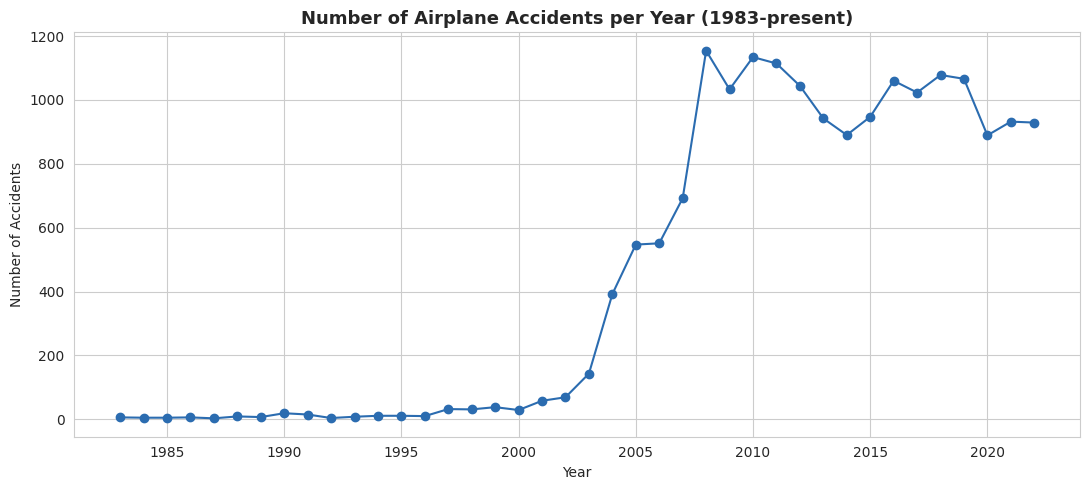

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
accidents_per_year.plot(kind='line', marker='o', ax=ax, color='#2b6cb0')
ax.set_title('Number of Airplane Accidents per Year (1983-present)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Accidents')
plt.tight_layout()
plt.show()


### Manufacturer risk comparison

We restrict to manufacturers with at least 100 recorded accidents (a stricter cut than the N>=50 cleaning threshold) so the chart highlights only well-supported comparisons.

/tmp/ipykernel_869/2266965835.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes['Avg_Severe_Injury_Rate'], y=top_makes.index, palette='RdYlGn_r', ax=ax)


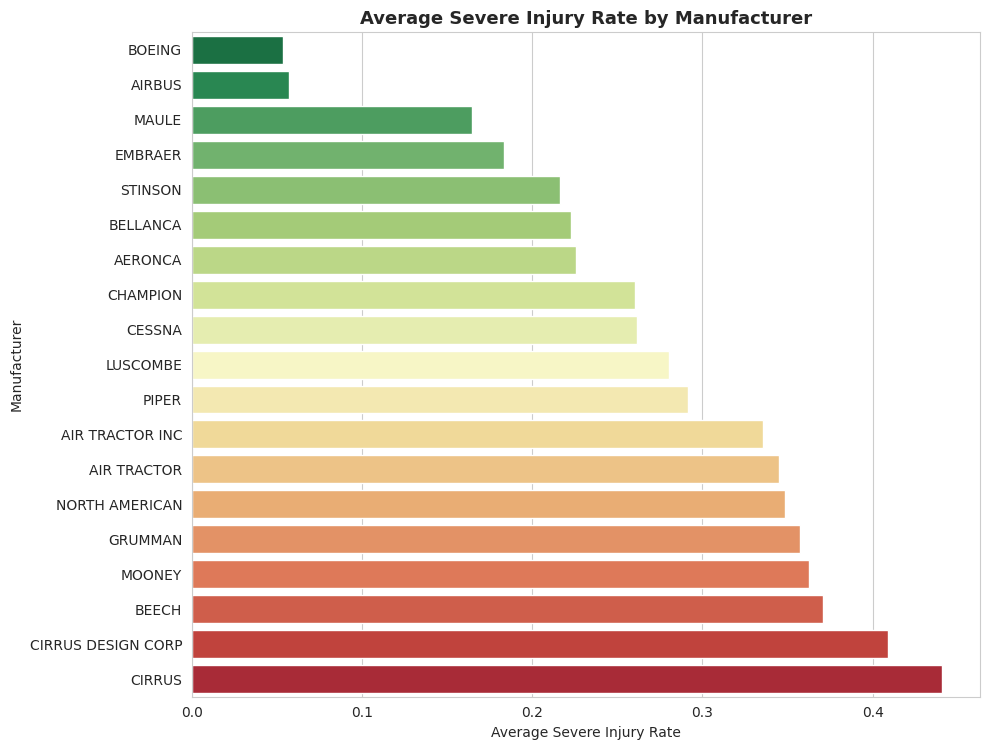

In [22]:
top_makes = make_stats[make_stats['Total_Accidents'] >= 100].sort_values('Avg_Severe_Injury_Rate')

fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(top_makes))))
sns.barplot(x=top_makes['Avg_Severe_Injury_Rate'], y=top_makes.index, palette='RdYlGn_r', ax=ax)
ax.set_title('Average Severe Injury Rate by Manufacturer', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Severe Injury Rate')
ax.set_ylabel('Manufacturer')
plt.tight_layout()
plt.show()


### Aircraft size vs. severe injury rate

/tmp/ipykernel_869/2541657130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_stats.index, y=size_stats['mean'], ax=axes[0], palette='Blues_d')


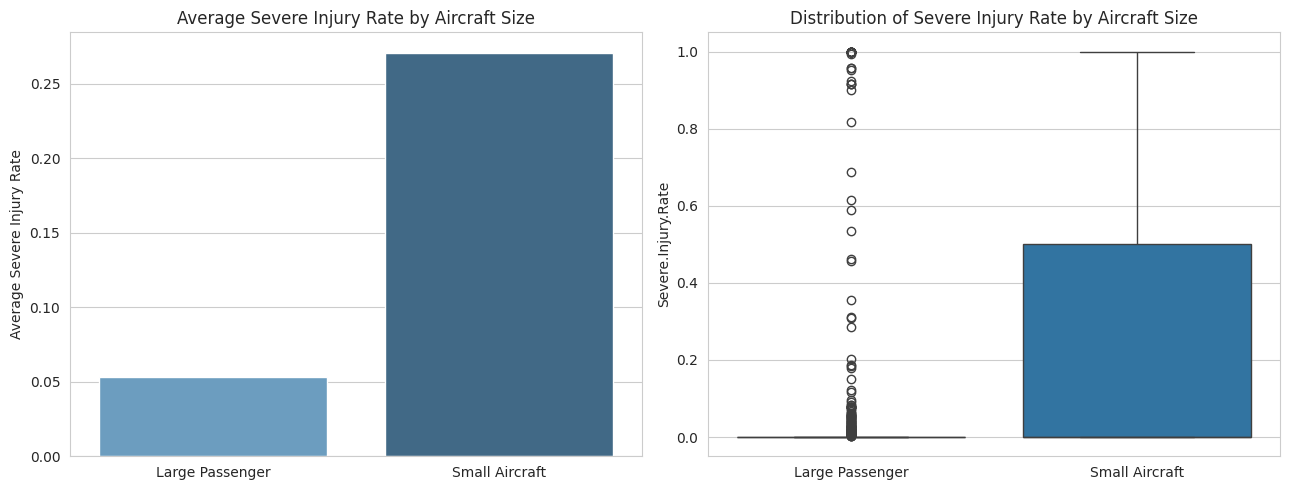

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=size_stats.index, y=size_stats['mean'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Severe Injury Rate by Aircraft Size')
axes[0].set_ylabel('Average Severe Injury Rate')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='Aircraft.Size', y='Severe.Injury.Rate', ax=axes[1])
axes[1].set_title('Distribution of Severe Injury Rate by Aircraft Size')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


### Weather condition impact

/tmp/ipykernel_869/4006952662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_stats.index, y=weather_stats['Avg_Fatalities'], palette='OrRd', ax=ax)


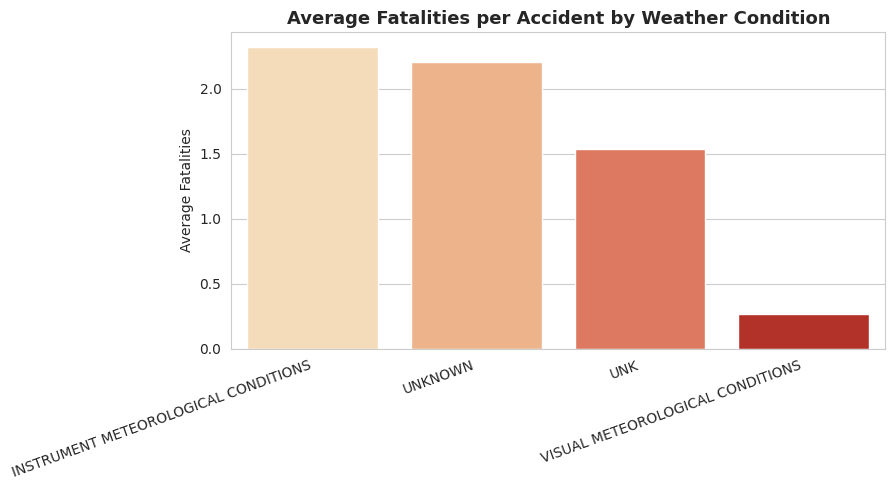

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=weather_stats.index, y=weather_stats['Avg_Fatalities'], palette='OrRd', ax=ax)
ax.set_title('Average Fatalities per Accident by Weather Condition', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Fatalities')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### Aircraft size x weather condition heatmap

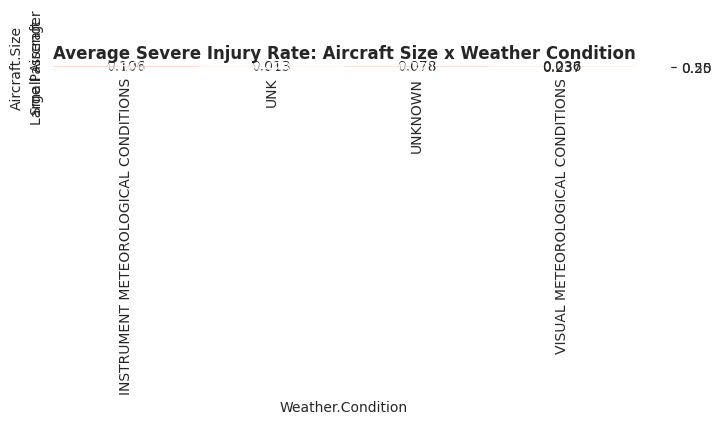

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(size_weather_pivot, annot=True, fmt='.3f', cmap='Reds', ax=ax)
ax.set_title('Average Severe Injury Rate: Aircraft Size x Weather Condition', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Accidents by phase of flight

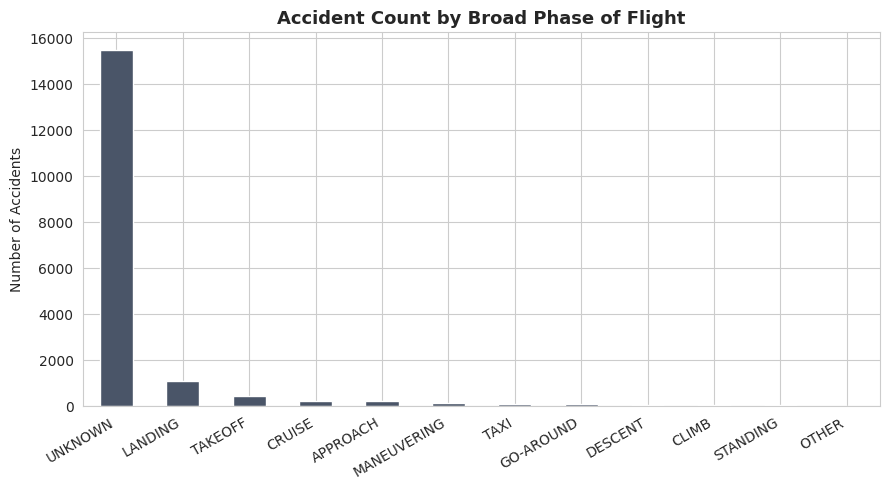

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
phase_stats.plot(kind='bar', ax=ax, color='#4a5568')
ax.set_title('Accident Count by Broad Phase of Flight', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Accidents')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Key Findings & Recommendations

- **Manufacturer risk varies meaningfully.** Some manufacturers show a consistently lower average severe injury rate across hundreds of recorded accidents these should be prioritized in any aircraft purchase shortlist. (See the manufacturer ranking table/chart above for the specific names based on your data.)
- **Large passenger aircraft show a lower per-occupant severe injury rate than small aircraft**, supporting the intuition that certified multi-engine commercial-scale aircraft are the safer category for the client's expansion, all else equal.
- **Weather conditions matter**: accidents occurring in instrument (low-visibility) conditions tend to carry higher average fatalities and destroyed-aircraft rates than those in visual conditions this supports operational policies favoring conservative weather minimums.
- **Takeoff and landing phases account for the largest share of accidents**, which should inform where pilot training and procedural safety investment is concentrated.

These findings are based on NTSB accident records from 1983-present, restricted to certified (non-amateur-built) airplanes, and to manufacturers with at least 50 recorded accidents for statistical reliability.

## Export cleaned data

In [27]:
df.to_csv('cleaned_aviation_accidents.csv', index=False)
print("Pipeline operation execution finalized. Data saved to 'cleaned_aviation_accidents.csv'.")


Pipeline operation execution finalized. Data saved to 'cleaned_aviation_accidents.csv'.
